# Regressione lineare con Gradient Descent — demo CCPP

Dimostrazione dal vivo del modulo di **regressione** del progetto.

Il modello (`LinearRegressionGD`), lo scaler, le metriche e la cross-validation sono **implementati da zero** nel package `src/`; qui vengono **importati** ed eseguiti sul dataset *Combined Cycle Power Plant* (CCPP).

**Filo del notebook** (stesso ordine delle slide): dati → preprocessing → addestramento → valutazione → confronto con sklearn → cross-validation → learning curve → feature engineering (AT²).

## 1. Setup e caricamento dati

La cartella superiore viene aggiunta al path di Python per poter **importare il codice da `src/`** (il notebook sta in `notebooks/`). Poi viene caricato il CSV: `X` = le 4 feature in input, `y` = il target PE (potenza erogata).

> Il modello NON è ridefinito qui, viene **importato**. Il notebook serve a *eseguire* la libreria, non a riscriverla.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))   # rende importabile il package src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# tutto il codice scritto da zero
from src.linear_regression_gd import LinearRegressionGD, normal_equation
from src.preprocessing import StandardScaler
from src.metrics import regression_report, rmse, r2_score
from src.model_selection import cross_validate

df = pd.read_csv('../data/raw/ccpp.csv')
X = df[['AT', 'V', 'AP', 'RH']].values   # 4 feature di input
y = df['PE'].values                      # target: potenza erogata (MW)
print('shape:', df.shape)
df.head(10)                                # stampa le prime 10 righe

shape: (9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90
5,26.27,59.44,1012.23,58.77,443.67
6,15.89,43.96,1014.02,75.24,467.35
7,9.48,44.71,1019.12,66.43,478.42
8,14.64,45.00,1021.78,41.25,475.98
9,11.74,43.56,1015.14,70.72,477.50


## 2. Esplorazione dei dati (EDA)

Prima di modellare, si visualizzano i dati per vedere:

1. **Le scale delle feature** (`describe`): se sono molto diverse, servirà lo scaling (S3).
2. **Quali feature contano** (`corr`) e **com'è la relazione** (scatter): guideranno il feature engineering (S9).

In [2]:
# statistiche descrittive: notare le scale molto diverse (AP ~1013, RH ~73, ...)
df.describe().round(2)

,AT,V,AP,RH,PE
count,9568.00,9568.00,9568.00,9568.00,9568.00
mean,19.65,54.31,1013.26,73.31,454.37
std,7.45,12.71,5.94,14.60,17.07
min,1.81,25.36,992.89,25.56,420.26
25%,13.51,41.74,1009.10,63.33,439.75
50%,20.34,52.08,1012.94,74.97,451.55
75%,25.72,66.54,1017.26,84.83,468.43
max,37.11,81.56,1033.30,100.16,495.76


In [3]:
# quanto ogni feature e' correlata col target PE
# (AT fortemente negativa: piu' caldo -> meno potenza)
df.corr()['PE'].sort_values() # coefficiente di correlazione di Pearson

AT   -0.948128
V    -0.869780
RH    0.389794
AP    0.518429
PE    1.000000
Name: PE, dtype: float64

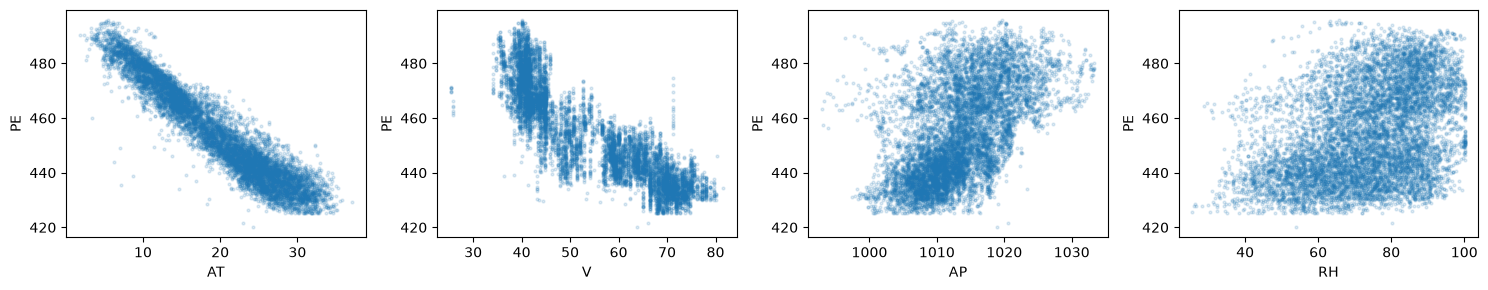

In [4]:
# relazione di ogni feature con PE:
fig, axes = plt.subplots(1, 4, figsize=(15, 3))
for ax, col in zip(axes, ['AT', 'V', 'AP', 'RH']):
    ax.scatter(df[col], df['PE'], s=4, alpha=0.15)
    ax.set_xlabel(col); ax.set_ylabel('PE')
plt.tight_layout(); plt.show()

È possibile notare, sia dalla scala delle features, sia dai grafici, che le feature hanno **scale diverse**. Il che suggerisce di implementare un processo di **standardizzazione** in fase di preprocessing.

## 3. Preprocessing: split e standardizzazione

Si dividono i dati in **train (80%)** e **test (20%)** con un seed fisso, in modo da rendere riproducibile lo split.

Poi si standardizza con lo z-score `(x - μ) / σ`. Per evitare il data-leakage media e deviazione standard si calcolano *solo sul training set* (`fit`) e si applicano anche al test (`transform`). Così nessuna informazione del test entra nel preprocessing.

In [5]:
rng = np.random.default_rng(42)          # genera un nymero casuale come seed
idx = rng.permutation(len(X))            # mescola le righe
n_test = int(0.2 * len(X))               # calcola il numero di righe da assegnare al test
test_idx, train_idx = idx[:n_test], idx[n_test:]   # 20% test, 80% train

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]     # estraggono dalle righe delle features e del target

scaler = StandardScaler().fit(X_train)   # impara mu, sigma SOLO dal train
X_train_s = scaler.transform(X_train)    # applica al train
X_test_s = scaler.transform(X_test)      # applica al test (stessi mu, sigma)
print('train:', X_train.shape, ' test:', X_test.shape)

train: (7655, 4)  test: (1913, 4)


## 4. Addestramento (Gradient Descent da zero)

Si addestra `LinearRegressionGD`. Il metodo `fit` esegue il **Batch Gradient Descent**: a ogni iterazione aggiorna i parametri θ nella direzione che riduce il costo J, e si ferma da solo quando J non cala più (test di convergenza con soglia ε).

Il grafico mostra J durante l'addestramento, in **scala logaritmica**: si vede J scendere di ~4 ordini di grandezza. (In scala lineare la discesa sembrerebbe istantanea — è un'illusione, la coda conta.)

iterazioni eseguite: 1005
theta_0 (intercetta): 454.248
coef (AT, V, AP, RH): [-14.587  -3.082   0.42   -2.278]


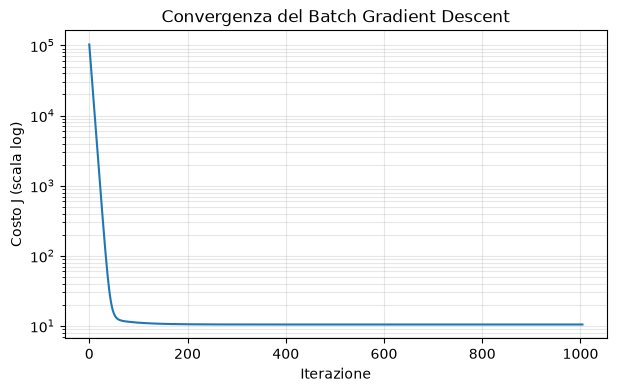

In [6]:
model = LinearRegressionGD(alpha=0.1, n_iters=2000, epsilon=1e-10)      
# alpha è il learning rate, epsilon è per l'early stopping, se l'errore diminuisce meno 
# di 10^(-10) tra un iterazione e l'altra il modello si ferma (arrivato al fondo della valle).
                                                                        
model.fit(X_train_s, y_train)            # l'addestramento con gradient descent

print('iterazioni eseguite:', model.n_iters_run_)         # si ferma prima delle 2000
print('theta_0 (intercetta):', round(model.intercept_, 3))
print('coef (AT, V, AP, RH):', np.round(model.coef_, 3))  # AT ha il peso piu' grande (in modulo)

plt.figure(figsize=(7, 4))
plt.plot(model.cost_history_)
plt.yscale('log')                        # scala log: mostra la discesa per intero
plt.xlabel('Iterazione'); plt.ylabel('Costo J (scala log)')
plt.title('Convergenza del Batch Gradient Descent')
plt.grid(True, alpha=0.3, which='both')
plt.show()

## 5. Valutazione sul test set

Si misura l'errore sui dati **mai visti** in addestramento. RMSE è in MW (l'unità del target); R² è la frazione di varianza spiegata (1 = perfetto, 0 = predice la media).

Lo scatter *predetto vs reale*: più i punti stanno sulla bisettrice, meglio è.

In [7]:
y_pred = model.predict(X_test_s)
# RMSE ~4.5 MW su PE ~420-495 -> errore relativo ~1%
{k: round(float(v), 4) for k, v in regression_report(y_test, y_pred).items()}

{'MSE': 20.0032, 'RMSE': 4.4725, 'R2': 0.9312}

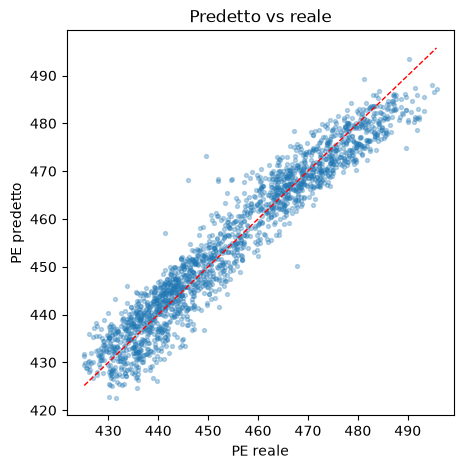

In [8]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, s=8, alpha=0.3)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', lw=1)        # bisettrice = predizione perfetta
plt.xlabel('PE reale'); plt.ylabel('PE predetto')
plt.title('Predetto vs reale'); plt.show()

## 6. Confronto a più vie

L'implementazione viene confrontata con: l'**equazione normale** (soluzione esatta in forma chiusa), `sklearn.LinearRegression` e **WEKA LinearRegression**.

**Perché è importante:** se l'implementazione è corretta, i numeri devono *coincidere*. Non è un caso — la funzione di costo è convessa, quindi ha un unico minimo globale e tutti i metodi corretti convergono allo stesso risultato.

> WEKA (v3.8.7, `weka.classifiers.functions.LinearRegression`, selezione attributi M5') è stato eseguito separatamente con split 80/20 interno. RMSE e R² coincidono con l'implementazione.

In [9]:
from sklearn.linear_model import LinearRegression

# soluzione in forma chiusa
theta_ne = normal_equation(X_train_s, y_train)
y_ne = theta_ne[0] + X_test_s @ theta_ne[1:]

# riferimento sklearn
sk = LinearRegression().fit(X_train_s, y_train)

rows = {
    'LinReg GD (da zero)':       regression_report(y_test, y_pred),
    'Equazione normale':         regression_report(y_test, y_ne),
    'sklearn LinearRegression':  regression_report(y_test, sk.predict(X_test_s)),
    # WEKA LinearRegression (v3.8.7, split 80/20, M5' attr. selection, no scaling)
    'WEKA LinearRegression':     {'MSE': round(4.4773**2, 4), 'RMSE': 4.4773, 'R2': round(0.965**2, 4)},
}
# i valori sono praticamente IDENTICI -> implementazione corretta
pd.DataFrame(rows).T[['R2', 'RMSE']].round(4)

,R2,RMSE
LinReg GD (da zero),0.9312,4.4725
Equazione normale,0.9312,4.4725
sklearn LinearRegression,0.9312,4.4725
WEKA LinearRegression,0.9312,4.4773


## 7. Cross-validation (5-fold)

Un solo split potrebbe essere fortunato/sfortunato. Con la **k-fold** si usano tutti i dati a rotazione (5 fold) e si ottiene una stima più affidabile, con la sua variabilità (media ± deviazione standard).

`preprocess=scale_train_val` fa sì che lo scaler venga **ri-adattato dentro ogni fold** (di nuovo: niente leakage).

In [10]:
def scale_train_val(Xtr, Xval):
    """Standardizza usando solo le statistiche del train del fold."""
    sc = StandardScaler().fit(Xtr)
    return sc.transform(Xtr), sc.transform(Xval)

# 'factory': serve un modello nuovo a ogni fold
factory = lambda: LinearRegressionGD(alpha=0.1, n_iters=2000, epsilon=1e-10)
cv_rmse = cross_validate(factory, X, y, scorer=rmse, preprocess=scale_train_val, k=5, random_state=42)
cv_r2 = cross_validate(factory, X, y, scorer=r2_score, preprocess=scale_train_val, k=5, random_state=42)

print('RMSE per fold:', np.round(cv_rmse, 4))
print(f'RMSE medio = {cv_rmse.mean():.4f} +/- {cv_rmse.std():.4f}')   # piccola std -> stabile
print(f'R2 medio   = {cv_r2.mean():.5f}')

RMSE per fold: [4.4755 4.7023 4.5507 4.5099 4.5547]
RMSE medio = 4.5586 +/- 0.0775
R2 medio   = 0.92856


## 8. Learning curve (diagnosi bias/variance)

Si addestra su sottoinsiemi di dimensione crescente `m` e si misura l'errore su *training* e su un *validation set fisso*. Come si legge:

- le due curve convergono a un errore **basso** → **low bias** (modello adeguato);
- il **gap** tra loro si chiude → **low variance** (no overfitting);
- diventano **piatte** → più dati non aiutano, si è al limite del modello lineare.

> Questa è la cella più lenta (~30s: tanti addestramenti). In demo conviene averla già eseguita.

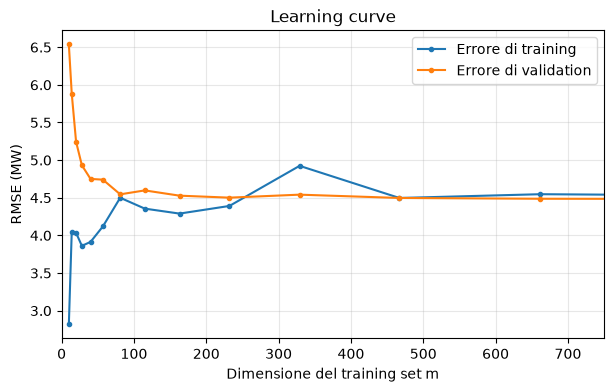

In [11]:
X_pool, y_pool = X[train_idx], y[train_idx]      # da qui peschiamo i sottoinsiemi
X_val, y_val = X[test_idx], y[test_idx]          # validation FISSO per tutte le dimensioni
sizes = sorted(set(int(s) for s in np.geomspace(10, len(X_pool), 20)))

tr_err, va_err = [], []
for m in sizes:
    a, b = [], []
    for r in range(5):                           # 5 ripetizioni -> curva piu' stabile
        sub = np.random.default_rng(r).choice(len(X_pool), m, replace=False)
        sc = StandardScaler().fit(X_pool[sub])
        mod = LinearRegressionGD(alpha=0.1, n_iters=2000, epsilon=1e-9).fit(sc.transform(X_pool[sub]), y_pool[sub])
        a.append(rmse(y_pool[sub], mod.predict(sc.transform(X_pool[sub]))))   # errore sul train
        b.append(rmse(y_val, mod.predict(sc.transform(X_val))))              # errore sul validation
    tr_err.append(np.mean(a)); va_err.append(np.mean(b))

plt.figure(figsize=(7, 4))
plt.plot(sizes, tr_err, '-o', ms=3, label='Errore di training')
plt.plot(sizes, va_err, '-o', ms=3, label='Errore di validation')
plt.xlim(0, 750)
plt.xlabel('Dimensione del training set m'); plt.ylabel('RMSE (MW)')
plt.title('Learning curve'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

## 9. Feature engineering: aggiungere AT²

Dalla learning curve si sa che l'errore residuo è **bias**: la relazione vera non è una retta. Per ridurlo si aggiunge al modello una **feature non lineare**, `AT²` (scelta perché AT è dominante e curva, vedi §2).

Importante: aggiungere `AT²` **non cambia l'algoritmo** — il modello resta lineare nei *parametri*, è la stessa `LinearRegressionGD` con una colonna in più.

Si confronta baseline (4 feature) vs +AT² (5 feature), e si disegna la funzione lungo AT: la retta che si piega in curva.

In [12]:
X_eng = np.hstack([X, (X[:, [0]]) ** 2])        # 4 feature + AT^2 (colonna 0 al quadrato)
Xtr_e, Xte_e = X_eng[train_idx], X_eng[test_idx]

sc_e = StandardScaler().fit(Xtr_e)
model_e = LinearRegressionGD(alpha=0.1, n_iters=5000, epsilon=1e-10).fit(sc_e.transform(Xtr_e), y_train)

rep = {
    'baseline (4 feat.)': regression_report(y_test, y_pred),
    '+ AT^2 (5 feat.)':   regression_report(y_test, model_e.predict(sc_e.transform(Xte_e))),
}
# R2 sale 0.931 -> 0.939, RMSE scende 4.47 -> 4.22
pd.DataFrame(rep).T[['R2', 'RMSE']].round(4)

,R2,RMSE
baseline (4 feat.),0.9312,4.4725
+ AT^2 (5 feat.),0.9387,4.2218


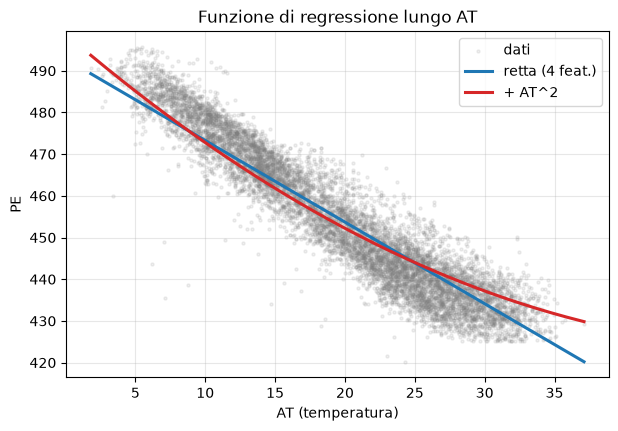

In [13]:
# la funzione appresa lungo AT, con le altre 3 feature fissate alla media
means = X.mean(axis=0)
at = np.linspace(X[:, 0].min(), X[:, 0].max(), 200)
grid = np.tile(means, (200, 1)); grid[:, 0] = at         # solo AT varia
grid_e = np.hstack([grid, (grid[:, [0]]) ** 2])          # versione con AT^2

plt.figure(figsize=(7, 4.5))
plt.scatter(X[:, 0], y, s=5, alpha=0.12, color='gray', label='dati')
plt.plot(at, model.predict(scaler.transform(grid)), color='tab:blue', lw=2.2, label='retta (4 feat.)')
plt.plot(at, model_e.predict(sc_e.transform(grid_e)), color='tab:red', lw=2.2, label='+ AT^2')
plt.xlabel('AT (temperatura)'); plt.ylabel('PE')
plt.title('Funzione di regressione lungo AT'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

### Predetto vs reale: baseline vs + AT^2

Si rivede lo scatter *predetto vs reale* (come al §5) ora **anche per il modello con AT²**, affiancato alla baseline: i punti del modello arricchito si stringono di più sulla bisettrice (predizione perfetta).

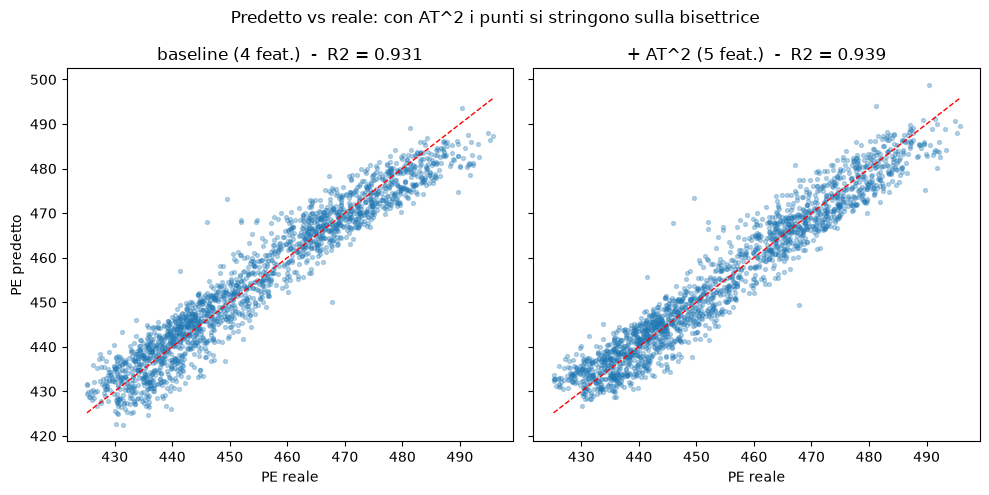

In [14]:
# Confronto predetto vs reale: baseline (4 feat.) vs + AT^2 (5 feat.)
y_pred_e = model_e.predict(sc_e.transform(Xte_e))   # predizioni del modello con AT^2
lims = [y_test.min(), y_test.max()]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
for ax, yp, titolo in [(axes[0], y_pred,   'baseline (4 feat.)'),
                       (axes[1], y_pred_e, '+ AT^2 (5 feat.)')]:
    ax.scatter(y_test, yp, s=8, alpha=0.3)
    ax.plot(lims, lims, 'r--', lw=1)        # bisettrice = predizione perfetta
    r2 = regression_report(y_test, yp)['R2']
    ax.set_xlabel('PE reale'); ax.set_title(f'{titolo}  -  R2 = {r2:.3f}')
axes[0].set_ylabel('PE predetto')
plt.suptitle('Predetto vs reale: con AT^2 i punti si stringono sulla bisettrice')
plt.tight_layout(); plt.show()

## 10. Conclusioni

- L'implementazione da zero **eguaglia** sklearn e l'equazione normale → corretta, converge al minimo globale.
- R² ≈ 0.93, RMSE ≈ 4.47 MW; stabile in 5-fold CV.
- La learning curve mostra **low bias / low variance** → niente overfitting, regolarizzazione non necessaria.
- Il **feature engineering** (AT²) riduce il bias: R² 0.931 → 0.939, RMSE 4.47 → 4.22 MW, senza overfitting.

*Tutta la teoria dietro questi passaggi è nelle slide; il notebook ne mostra l'esecuzione sul CCPP.*